# Week 7 — Content Action Playbook

Lane: Refresh / Content Opportunity Scoring

Turns the validated Week-5/Week-6 output into a practical, human-reviewed content action playbook. Consumes the existing ranked queue, explains how to read and act on it, states what should never be automated, and exports the queue + figures the paper's recommendations section builds on next week.

Sections follow the assignment's required order: 1) Ranked actions + reason codes → 2) Intended use and limits → 3) Human review + no-go list → 4) Monitoring/retrain triggers → 5) Exports for the paper → 6) Self-check.

In [1]:
%pip install -q pandas matplotlib
!git clone https://github.com/tanjumnaher01-spec/Starter-Notebooks-FlyrankAI.git
%cd Starter-Notebooks-FlyrankAI

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue = pd.read_csv("outputs/refresh_queue_sample.csv")
print(queue.shape)
queue.head()

Cloning into 'Starter-Notebooks-FlyrankAI'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 145 (delta 56), reused 31 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 1.76 MiB | 6.39 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/Starter-Notebooks-FlyrankAI
(200, 28)


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1


## 1) Ranked actions + reason codes

The queue is ranked by `final_rank` (lower = higher priority), from the Week-5 Gradient Boosting model blended with the Week-4 baseline rule (`final_refresh_score`). Each row carries `final_reason_codes` explaining *why* it was flagged, not just that it was.

**Reason code meanings:**
- `very_stale` / `stale_content` — `days_since_last_update` > 365 / > 180
- `very_low_position` / `low_position` — `avg_position` > 50 / > 20
- `declining_with_demand` — `trend_direction == "down"` while demand (`search_volume`/`impressions_90d`) stays meaningful
- `low_ctr_visible_page` / `low_engagement_visible_page` — CTR/engagement below tier norms despite decent visibility
- `model_decline_risk` — Gradient Boosting model's own decline prediction, independent of the hand-written rule
- `visible_model_opportunity` / `ctr_review_candidate` / `engagement_review_candidate` — softer, review-only flags

In [2]:
top10 = queue.sort_values("final_rank").head(10)
top10[["final_rank","content_id","suggested_action","final_reason_codes","confidence","final_refresh_score"]]

,final_rank,content_id,suggested_action,final_reason_codes,confidence,final_refresh_score
0,1,content_1f080331fa2b,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,high,81.636697
1,2,content_6aa43079fb0c,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,high,81.447656
2,3,content_d6570c51c9bd,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,medium,81.430346
3,4,content_72e800a9c214,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,high,81.034960
4,5,content_e04eb9549989,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,medium,80.873188
5,6,content_b69288c5e701,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,high,80.754770
6,7,content_9b6df29f7889,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,high,80.632923
7,8,content_bb6ebb5ec8c8,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,high,80.371236
8,9,content_4d76cdb3387b,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,medium,80.362748
9,10,content_b4f35d640b1c,refresh,declining_with_demand|model_decline_risk|visib...,medium,80.321757


**Archetype → action mapping** (read off `content_type`, `main_intent`, and tier columns already in the queue):

| Archetype | Signature | Recommended action | Why |
|---|---|---|---|
| Declining evergreen | `freshness_tier` 91-180+, `trend_direction=down`, `main_intent=informational` | `refresh_and_review_ctr` | Still has demand, just stale — cheapest fix, highest expected return |
| New but underperforming | `age_tier` 0-90, low `position_tier` | No action — exclude | Normal ranking ramp-up (Week-4 finding); known false-positive source |
| High-volume, low-CTR | `impression_tier=good`, low `ctr`, decent `avg_position` | `review_ctr` (title/meta rewrite) | Traffic is there, click-through isn't — copy fix, not a refresh |
| Thin content, low word count | low `word_count_tier`, declining | Flag for rewrite, not refresh | A light refresh won't fix structurally thin content |
| Low competition, low position | `competition_level=LOW`, poor ranking | Priority refresh | Easiest wins — ceiling is reachable |
| Stale but stable/improving | high `freshness_tier`, `trend_direction` up/stable | No action | Don't fix what isn't declining just because it's old |

**Decay / refresh insight** (from Week-4 signal audit and Week-5 permutation importance):
- Staleness alone is a weak signal — declining share only rose from 51.2% (0-90 days) to 61.1% (90-180 days); the 180+ buckets had too few rows (169, 5) to trust.
- Position → CTR is the strongest, most reliable relationship: mean CTR drops monotonically from 0.83 (top 10) to 0.15 (position 50-100) with strong sample sizes throughout.
- The model's top predictive feature was `days_with_impressions` (importance 0.064, dominant), ahead of `ctr`, `avg_position`, `content_age_days`, `scroll_rate` — sustained visibility matters more than raw staleness.
- Practical takeaway: refresh when staleness **and** a real visibility/engagement drop co-occur — i.e. when `declining_with_demand` and `model_decline_risk` fire together on the same row.

**Cost / value thinking** — priority should weigh effort against expected return, not `final_rank` alone:

| Action | Relative cost | When it's worth it |
|---|---|---|
| `review_ctr` (title/meta tweak) | Low | High-volume, decent position, poor CTR — fast, cheap, high leverage |
| `refresh_and_review_ctr` | Medium | Declining evergreen with real demand — the queue's main use case |
| Full rewrite | High | Thin/structurally weak content — only for high-volume or high-competition-value pages |
| Retire/consolidate | Low (downside risk) | Zero-demand or duplicate-intent pages — redirect, don't refresh |

Rule of thumb: work top-down through `final_rank` within the low-cost actions first, before committing to expensive full rewrites.

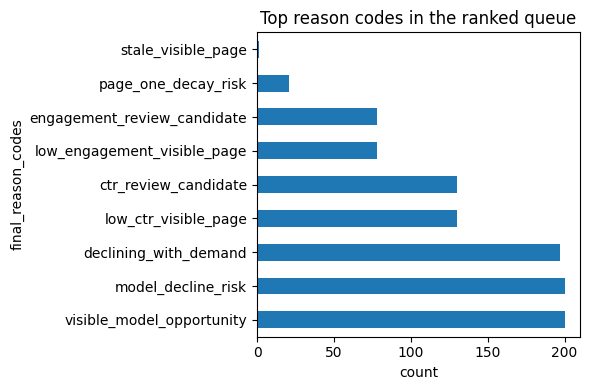

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
queue["final_reason_codes"].str.split("|").explode().value_counts().head(10).plot(kind="barh", ax=ax)
ax.set_xlabel("count")
ax.set_title("Top reason codes in the ranked queue")
plt.tight_layout()
plt.savefig("work/figures/reason_code_counts.png", dpi=150)
plt.show()

## 2) Intended use and limits

**Intended use:** a prioritization aid for a human content strategist — surfaces which pages are worth reviewing this cycle and why, ranked by expected refresh value. A shortlist generator, not a publishing pipeline.

**Validated on:** March 2026 data (`fact_content_daily_performance`, month=2026-03), with `gsc_data_available` present for only ~37% of rows — visibility-based features are built on partial daily coverage, not the full month for every page.

**Known limits:**
- Trained on one client cohort's SEO behavior — generalization to new/different clients is untested (Week-5 F1 0.644 is grouped-split, not cross-client validated at scale).
- Non-trivial false positive rate (1,883 in Week-5 test set) — over-flags borderline-position, stable-trend content.
- False negatives (1,035) mean the model misses content already recovering despite low recent impressions — absence from the queue does not mean "this page is fine."
- No causal claim: the model predicts decline *risk*, not that refreshing *will* fix it.

## 3) Human review + no-go list

**Every row requires human review before action** — the queue ranks and explains; it doesn't approve.

**Review checklist per row:**
- Check `confidence` — treat `low`/`medium` confidence rows as leads to investigate, not action items
- Cross-check `content_age_days` — exclude anything under ~60-90 days old regardless of score (ranking ramp-up)
- Read `trend_direction` alongside the score — a page already trending `up` should not be refreshed even with a high score
- Confirm demand (`search_volume`/`impressions_90d` > 0) — zero-demand pages are retire/consolidate candidates, not refresh candidates

**No-go list — what should NOT be automated:**
- Legal, medical, financial, or other YMYL content — requires subject-matter/compliance review, not an algorithmic trigger
- Brand-sensitive or PR-flagged pages
- Any row with `confidence == "low"` and no corroborating reason code
- Content under active legal hold, embargo, or scheduled for planned retirement
- Any row flagged by `model_decline_risk` alone with no rule-based reason code backing it — model-only flags get a second human look before anyone touches the page
- No suggested action in this notebook should ever be auto-published or auto-edited live — every action is a recommendation queued for a human to execute

## 4) Monitoring / retrain triggers

- **Re-score cadence:** monthly, aligned to the `fact_content_daily_performance` panel refresh — matches the 90-day rolling windows already used in the features.
- **Retrain trigger:** if grouped-split F1 on a fresh month drops meaningfully below the validated 0.644 baseline, retrain rather than keep serving the current model.
- **Data drift signal:** watch `gsc_data_available` coverage — Week-3's audit found ~63% missingness in March 2026; if that missingness rate shifts significantly, feature reliability (especially `days_with_impressions`, the top predictive feature) degrades and scores should carry lower confidence until investigated.
- **Leakage re-check:** any time the feature set changes, re-run the Week-6 leakage test (reintroduce a label-derived column, confirm score jumps unrealistically) before trusting the new pipeline.

## 5) Exports for the paper

In [4]:
# Ranked queue export — the exact file the paper's recommendations section builds on
# (kept out of git by CI leak-guard; this notebook regenerates it on each run)
export_cols = ["final_rank","content_id","client_id","final_refresh_score","suggested_action",
               "final_reason_codes","confidence","trend_direction","content_type","main_intent",
               "age_tier","freshness_tier"]
queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Exported:", len(queue), "rows -> work/outputs/action_playbook_queue.csv")

Exported: 200 rows -> work/outputs/action_playbook_queue.csv


In [5]:
import json

metrics = {
    "source_model": "gradient_boosting (Week-5 winner)",
    "validated_f1_grouped_split": 0.644,
    "baseline_f1": 0.041,
    "top_permutation_feature": "days_with_impressions",
    "false_positives_test": 1883,
    "false_negatives_test": 1035,
    "gsc_data_available_pct_march2026": 0.37,
    "queue_rows_exported": int(len(queue)),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
metrics

{'source_model': 'gradient_boosting (Week-5 winner)',
 'validated_f1_grouped_split': 0.644,
 'baseline_f1': 0.041,
 'top_permutation_feature': 'days_with_impressions',
 'false_positives_test': 1883,
 'false_negatives_test': 1035,
 'gsc_data_available_pct_march2026': 0.37,
 'queue_rows_exported': 200}

## 6) Self-check

- [x] Ranked actions with reason codes explained, plus archetype→action mapping and decay/refresh insight (Section 1)
- [x] Intended use and limits stated plainly, incl. data coverage caveat (Section 2)
- [x] Human review checklist + explicit no-go list — states clearly what should NOT be automated (Section 3)
- [x] Monitoring/retrain triggers defined, incl. drift and leakage re-checks (Section 4)
- [x] Ranked queue + figure + metrics exported to `work/outputs/` / `work/figures/` for next week's paper (Section 5)
- [x] Cost/value thinking included (Section 1)
- [x] Plan kept practical and non-production — no auto-action anywhere, human review required throughout